# Regression problem with FNN

This problem/dataset contains samples of 13 attributes of houses at different locations around the Boston suburbs in the late 1970s. Targets are the median values of the houses at a location (in k$).

that may appear to assume that racial self-segregation influences house prices.
As such, we strongly discourage the use of this dataset, unless in the context of illustrating
ethical issues in data science and machine learning.

## Setup

In [4]:
import tensorflow as tf  # Import TensorFlow library
import numpy as np  # Import NumPy library
import matplotlib.pyplot as plt  # Import matplotlib library for plotting

from tensorflow.keras import Sequential  # Import Sequential model from TensorFlow's Keras API
from tensorflow.keras.layers import Input, Dense, Dropout  # Import Dense and Dropout layers from TensorFlow's Keras API

## Load and prepare data

In [ ]:
# Load data from TensorFlow's Boston Housing dataset
housing_data = tf.keras.datasets.boston_housing

# Split the data into training and testing sets
(x_train, y_train), (x_test, y_test) = housing_data.load_data()

# Print the shape of the training and testing data
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

# Print the first sample of the training data
print("First sample of x_train:", x_train[0,:])

# Print the targets for the training data
print("Targets for y_train:", y_train)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (404, 13)
x_test shape: (102, 13)
First sample of x_train: [  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]
Targets for y_train: [15.2 42.3 50.  21.1 17.7 18.5 11.3 15.6 15.6 14.4 12.1 17.9 23.1 19.9
 15.7  8.8 50.  22.5 24.1 27.5 10.9 30.8 32.9 24.  18.5 13.3 22.9 34.7
 16.6 17.5 22.3 16.1 14.9 23.1 34.9 25.  13.9 13.1 20.4 20.  15.2 24.7
 22.2 16.7 12.7 15.6 18.4 21.  30.1 15.1 18.7  9.6 31.5 24.8 19.1 22.
 14.5 11.  32.  29.4 20.3 24.4 14.6 19.5 14.1 14.3 15.6 10.5  6.3 19.3
 19.3 13.4 36.4 17.8 13.5 16.5  8.3 14.3 16.  13.4 28.6 43.5 20.2 22.
 23.  20.7 12.5 48.5 14.6 13.4 23.7 50.  21.7 39.8 38.7 22.2 34.9 22.5
 31.1 28.7 46.  41.7 21.  26.6 15.  24.4 13.3 21.2 11.7 21.7 19.4 50.
 22.8 19.7 24.7 36.2 14.2 18.9 18.3 20.6 24.6 18.2  8.7 44.  10.4 13.2
 21.2 37.  30.7 22.9 20.  19.3 31.7 32.  23.1 18.8 10.9 50.  19.6  5.
 14.4 19.8 13.8 19.6 23.9

Normalize the data

In [ ]:
# Normalize the data by subtracting the mean and dividing by the standard deviation
# also using scikit and its scalling mechanism is possible
def normalize(x):
  return (x - np.mean(x)) / np.std(x)

# Normalize the training and testing data
normed_x_train = normalize(x_train)
normed_x_test = normalize(x_test)

## BUILD MODEL

In [3]:
# Define a Sequential model
model = Sequential()
model.add(Input(shape=(x_train.shape[1],))) #input layer
# Add the first hidden layer with 32 neurons, 'relu' activation function, and input shape equal to the number of features in the training data
model.add(Dense(32, activation='relu'))
# Add the second hidden layer with 16 neurons and 'relu' activation function
model.add(Dense(16, activation='relu'))
# Add the output layer with 1 neuron and linear activation function (default)
model.add(Dense(1))

# Compile the model with 'rmsprop' optimizer, 'mse' loss function, and 'mae' metric
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
# model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

NameError: name 'Sequential' is not defined

Train model

In [2]:
# Train the model on the training data for 100 epochs with a batch size of 32, and validate on the testing data
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=16, verbose=1)

NameError: name 'model' is not defined

In [1]:
# Print the keys in the history dictionary
print(history.history.keys())

NameError: name 'history' is not defined

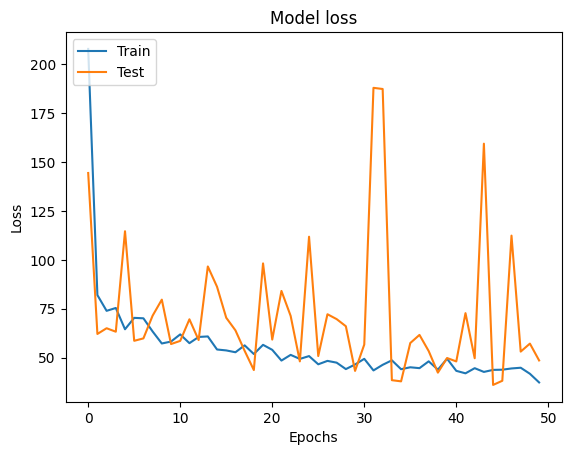

In [ ]:
# Plot the training and validation loss over the number of epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model on the training and testing data
error_train = model.evaluate(x_train, y_train, verbose=0)
error_test = model.evaluate(x_test, y_test, verbose=0)

# Print the mean absolute error on the training and testing data
print("Training error:", error_train[1])
print("Testing error:", error_test[1])

Training error: 5.731436729431152
Testing error: 5.904876232147217


In [ ]:
# BONUS

# =============================================================================
# CROSS VALIDATED MODEL
# =============================================================================

In [ ]:
# Build model
def build_model():
    model = Sequential()
    model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
    #model.add(Dense(1280, activation='relu'))
    model.add(Dense(16, activation='relu'))
    #model.add(Dense(64, activation='relu'))
    #model.add(Dropout(0.3))
    model.add(Dense(1)) # default activation: linear

    # Compile the model
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    # Return the model
    return model

In [ ]:
# Concatenate the normalized training and testing data along the 0th axis
normed_x = np.concatenate((normed_x_train, normed_x_test), axis=0)

# Concatenate the training and testing targets along the 0th axis
y = np.concatenate((y_train, y_test), axis=0)

# Import KFold from scikit-learn
from sklearn.model_selection import KFold

# Define the number of splits for cross-validation
n_split = 4

# Initialize an empty list to store the scores
scores = []

# Define the number of epochs
num_epochs = 100

# Perform k-fold cross-validation
for train_index, test_index in KFold(n_split).split(normed_x):
    # Split the data into training and testing sets based on the current fold
    x_train, x_test = normed_x[train_index], normed_x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Build the model
    model = build_model()

    # Train the model on the training data for the current fold
    model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=32, epochs=num_epochs, verbose=0)

    # Evaluate the model on the testing data for the current fold
    val_mse, val_mae = model.evaluate(x_test, y_test, verbose=0)

    # Print the evaluation metric for the current fold
    print('Model evaluation', val_mae)

    # Append the score to the list of scores
    scores.append(val_mae)

# Print the list of scores and the mean score
print(scores, np.mean(scores))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model evaluation 5.60740327835083
Model evaluation 4.983342170715332
Model evaluation 6.232097148895264
Model evaluation 4.99687385559082
[5.60740327835083, 4.983342170715332, 6.232097148895264, 4.99687385559082] 5.4549291133880615


In [ ]:
'''
In this code, you are defining a function `build_model` to create a Sequential model
with two hidden layers and one output layer. The model is compiled with the
'rmsprop' optimizer, 'mse' loss function, and 'mae' metric. You are then concatenating
the normalized training and testing data and targets, and performing k-fold cross-validation
with 4 splits. For each fold, you are building the model, training it on the training data,
and evaluating it on the testing data. The evaluation metric for each fold is printed,
and the scores are stored in a list. Finally, the list of scores and the mean score are printed.
'''

"\nIn this code, you are defining a function `build_model` to create a Sequential model\nwith two hidden layers and one output layer. The model is compiled with the\n'rmsprop' optimizer, 'mse' loss function, and 'mae' metric. You are then concatenating\nthe normalized training and testing data and targets, and performing k-fold cross-validation\nwith 4 splits. For each fold, you are building the model, training it on the training data,\nand evaluating it on the testing data. The evaluation metric for each fold is printed,\nand the scores are stored in a list. Finally, the list of scores and the mean score are printed.\n"

In [ ]:
# =============================================================================
# CROSS VALIDATED MODEL WITH HISTORY
# =============================================================================

In [ ]:
def build_model():
    model = Sequential()
    model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
    #model.add(Dense(1280, activation='relu'))
    model.add(Dense(16, activation='relu'))
    #model.add(Dense(64, activation='relu'))
    #model.add(Dropout(0.3))
    model.add(Dense(1)) # default activation: linear
    # compile the model
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [ ]:
normed_x = np.concatenate((normed_x_train, normed_x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

from sklearn.model_selection import KFold

n_split=4

scores = []
all_mae_histories = []
num_epochs = 100

# Let's collect the histories of the k-fold splits
for train_index,test_index in KFold(n_split).split(normed_x):
  x_train,x_test=normed_x[train_index],normed_x[test_index]
  y_train,y_test=y[train_index],y[test_index]

  model=build_model()
  history = model.fit(x_train, y_train,validation_data=(x_test, y_test), batch_size=32, epochs=num_epochs, verbose=0)
  mae_history = history.history['val_mae']
  all_mae_histories.append(mae_history)

# Average over all histories
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]
print(average_mae_history[-1:])

[np.float64(5.310775995254517)]


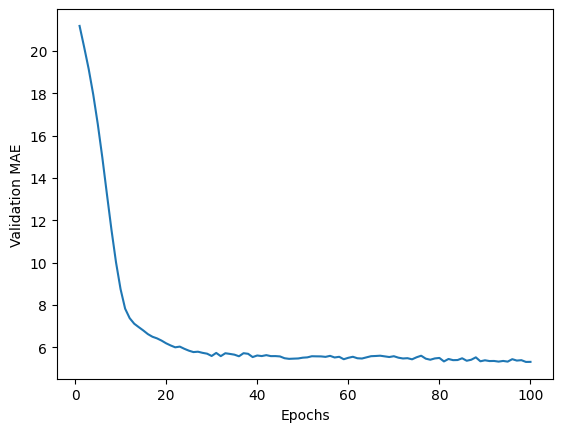

In [ ]:
# Plot validation MAE
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

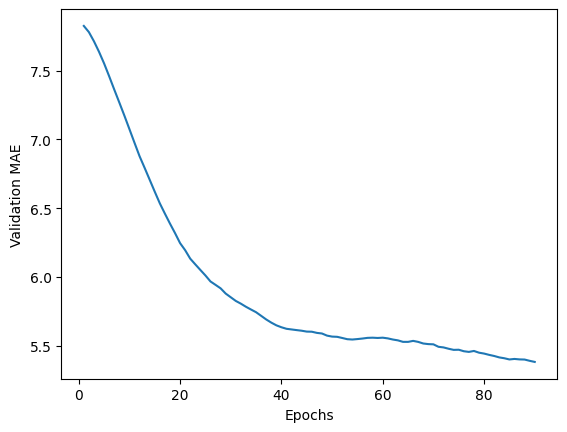

In [ ]:
# Function to smooth the loss curve
def smooth_curve(points, factor=0.9):
  smoothed_points = []
  for point in points:
    if smoothed_points:
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else:
      smoothed_points.append(point)
  return smoothed_points

smooth_mae_history = smooth_curve(average_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()